# 随机 8-SAT + Sparrow TTS
1. 随机生成 `k=8`、`r=m/n=176` 的 8-SAT 实例。
2. 复现论文 Eq. (1) 的 Sparrow 中位 TTS 公式。

In [30]:
import numpy as np

# 画图模块；如果 kernel 里没有 matplotlib，就跳过图像但不影响数值计算
try:
    import matplotlib.pyplot as plt
except Exception as exc:
    plt = None
    print("matplotlib 未安装或不可用，跳过图像:", exc)

# 检查 Qiskit 环境；本简化版不实际使用 Qiskit 电路
try:
    import qiskit
    print("Qiskit version:", qiskit.__version__)
except Exception as exc:
    print("Qiskit 未安装或不可用:", exc)

Qiskit version: 2.3.0


In [31]:
# 论文固定的 8-SAT 参数
K = 8
R = 176

# Sparrow 中位 TTS 的拟合参数，单位是 ns
SPARROW_SLOPE = 0.176
SPARROW_INTERCEPT = 19.369

# 论文原始 CPU 配置：AMD EPYC 7R32
AMD_CORES = 48
AMD_TDP_W = 280.0
AMD_W_PER_CORE = AMD_TDP_W / AMD_CORES

# Rand-9 并行化模型的移位指数分布参数
RAND9_LAMBDA = 9.8e-4
RAND9_X0 = 6.8

In [32]:
# 按论文 Methods IV.F.b 生成随机 8-SAT
def generate_8sat(n: int, seed: int = 0):
    rng = np.random.default_rng(seed)
    m = R * n
    clauses = rng.integers(0, n, size=(m, K), dtype=np.int64)
    negated = rng.random((m, K)) < 0.5
    return clauses, negated


# 判断一组布尔赋值是否满足全部 clause
def is_satisfied(clauses, negated, assignment):
    variable_values = assignment[clauses]
    literal_values = np.where(negated, ~variable_values, variable_values)
    return bool(np.all(literal_values.any(axis=1)))


# 用一个 n=8 的小实例验证生成器，暴力搜索一个可满足赋值
n_demo = 8
clauses, negated = generate_8sat(n_demo, seed=1)
found = None
for bits in range(1 << n_demo):
    assignment = np.zeros(n_demo, dtype=bool)
    for i in range(n_demo):
        assignment[i] = bool((bits >> i) & 1)
    if is_satisfied(clauses, negated, assignment):
        found = assignment
        break

print("n =", n_demo, ", m =", len(clauses))
print("找到可满足赋值:", "".join("1" if bit else "0" for bit in found) if found is not None else "无")

n = 8 , m = 1408
找到可满足赋值: 10011100


In [33]:
# 论文 Eq. (1)：Sparrow 中位 TTS，返回 ns
def sparrow_tts_ns(n: float) -> float:
    return float(2.0 ** (SPARROW_SLOPE * n + SPARROW_INTERCEPT))


# 打印几个典型 n 的 TTS 和小时数
print(f"{'n':>4} {'log2 T_c(ns)':>13} {'T_c(ns)':>18} {'T_c(hours)':>16}")
for n in [30, 40, 50, 60, 70, 179]:
    tts_ns = sparrow_tts_ns(n)
    print(f"{n:4d} {np.log2(tts_ns):13.3f} {tts_ns:18.6e} {tts_ns / 1e9 / 3600:16.6g}")

   n  log2 T_c(ns)            T_c(ns)       T_c(hours)
  30        24.649       2.630803e+07      7.30779e-06
  40        26.409       8.910481e+07      2.47513e-05
  50        28.169       3.017963e+08      8.38323e-05
  60        29.929       1.022178e+09      0.000283938
  70        31.689       3.462099e+09      0.000961694
 179        50.873       2.062049e+15          572.791


In [34]:
# 简化版并行演示：Rand-9 移位指数模型
# 单次搜索平均时间 = x0 + 1/lambda
# n_cores 个独立搜索的最短时间 = x0 + 1/(n_cores * lambda)
def rand9_speedup(n_cores: int) -> float:
    single = RAND9_X0 + 1.0 / RAND9_LAMBDA
    parallel_min = RAND9_X0 + 1.0 / (n_cores * RAND9_LAMBDA)
    return single / parallel_min


print("Rand-9 并行加速比：")
for cores in [1, AMD_CORES, 71]:
    label = "论文 AMD 48 核" if cores == AMD_CORES else f"{cores} 核"
    print(f"{label:>16}: {rand9_speedup(cores):.3f}x")

Rand-9 并行加速比：
             1 核: 1.000x
     论文 AMD 48 核: 36.610x
            71 核: 48.517x


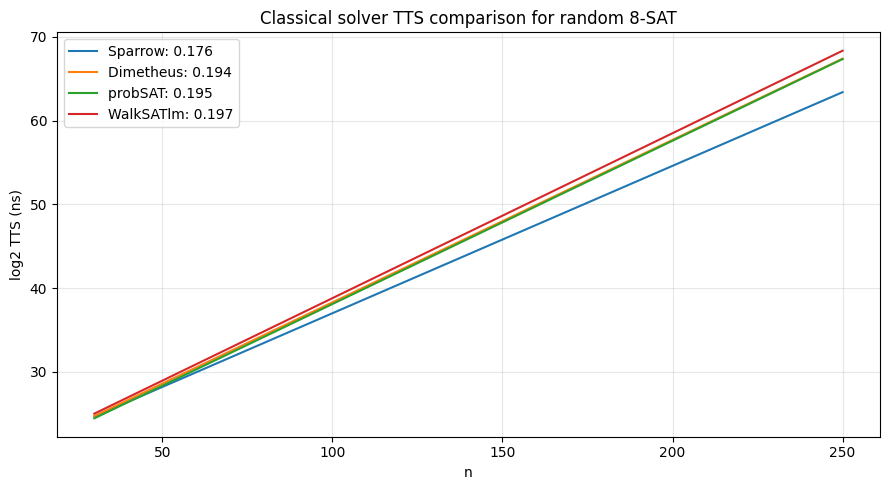

In [35]:
# 论文 Fig.1A 风格的经典求解器对比图
# Rand-9 只用于上面的数值估算，不作为论文图单独绘制

if plt is None:
    print("matplotlib 不可用，跳过经典求解器对比图。")
else:
    ns = np.linspace(30, 250, 300)

    # 几个经典求解器的指数拟合参数
    solvers = {
        "Sparrow": (0.176, 19.4),
        "Dimetheus": (0.194, 18.9),
        "probSAT": (0.195, 18.6),
        "WalkSATlm": (0.197, 19.1),
    }

    fig, ax = plt.subplots(figsize=(9, 5))
    for name, (slope, intercept) in solvers.items():
        log2_tts = slope * ns + intercept
        ax.plot(ns, log2_tts, label=f"{name}: {slope}")

    ax.set_xlabel("n")
    ax.set_ylabel("log2 TTS (ns)")
    ax.set_title("Classical solver TTS comparison for random 8-SAT")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.savefig("paper_figures_repro.png", dpi=200, bbox_inches="tight")
    plt.show()